# 02 — Exploratory Data Analysis
## Patient No-Show & Clinic Efficiency Analysis

**Objective:** answer the business questions from Phase 0 in order — overall attendance, then patient
demographics, then scheduling/behavioral factors, then location and medical history — using the cleaned
dataset from Notebook 01.

**Approach:** EDA here isn't "make some charts." Each section exists to answer a specific stakeholder
question. We report the actual numbers the data produces, flag small-sample results as unreliable, and are
explicit that this is observational analysis (association, not causation).

**Input:** `data/cleaned/cleaned_appointments.csv` (110,521 rows, produced by Notebook 01).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

CHARTS_DIR = '../outputs/charts'
import os
os.makedirs(CHARTS_DIR, exist_ok=True)

df = pd.read_csv('../data/cleaned/cleaned_appointments.csv', parse_dates=['scheduled_day','appointment_day'])
print("Shape:", df.shape)
df.head(3)


Shape: (110521, 24)


,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show,no_show_flag,lead_time_days,appointment_weekday,appointment_month,appointment_year,age_group,waiting_time_group,reminder_flag,scholarship_flag,chronic_condition_count
0,29872499824296,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0,0,Friday,April,2016,51-65 Senior,Same day,0,0,1
1,558997776694438,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,0,Friday,April,2016,51-65 Senior,Same day,0,0,0
2,4262962299951,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,0,Friday,April,2016,51-65 Senior,Same day,0,0,0


## A. Overall Attendance

**Business question:** How large is the no-show problem overall?


Total appointments: 110,521
Show-ups: 88,207
No-shows: 22,314
No-show rate: 20.19%
Show rate: 79.81%


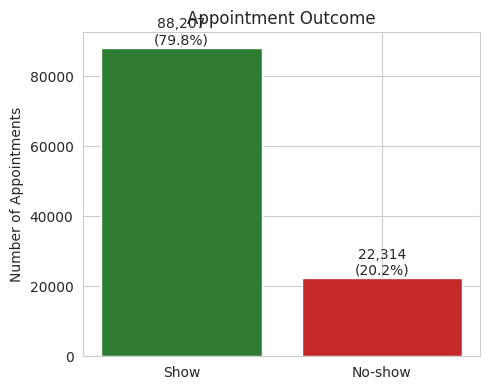

In [2]:
total_appts = len(df)
show_ups = (df['no_show_flag'] == 0).sum()
no_shows = (df['no_show_flag'] == 1).sum()
no_show_rate = no_shows / total_appts
show_rate = show_ups / total_appts

print(f"Total appointments: {total_appts:,}")
print(f"Show-ups: {show_ups:,}")
print(f"No-shows: {no_shows:,}")
print(f"No-show rate: {no_show_rate:.2%}")
print(f"Show rate: {show_rate:.2%}")

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(['Show', 'No-show'], [show_ups, no_shows], color=['#2E7D32','#C62828'])
ax.set_title('Appointment Outcome')
ax.set_ylabel('Number of Appointments')
for i, v in enumerate([show_ups, no_shows]):
    ax.text(i, v + 1000, f"{v:,}\n({v/total_appts:.1%})", ha='center')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/A_overall_attendance.png')
plt.show()


**Key insight:** roughly **1 in 5 appointments (20.19%)** end in a no-show. This is the baseline
against which every other segment in this notebook is compared.

## B. Age Analysis

**Business question:** Which age groups are more likely to miss appointments?


                   volume  no_show_rate
age_group                              
0-12 Child          21035        0.2047
13-18 Teen           7830        0.2605
19-35 Young Adult   24135        0.2383
36-50 Adult         22099        0.2032
51-65 Senior        22122        0.1655
66+ Elderly         13300        0.1553


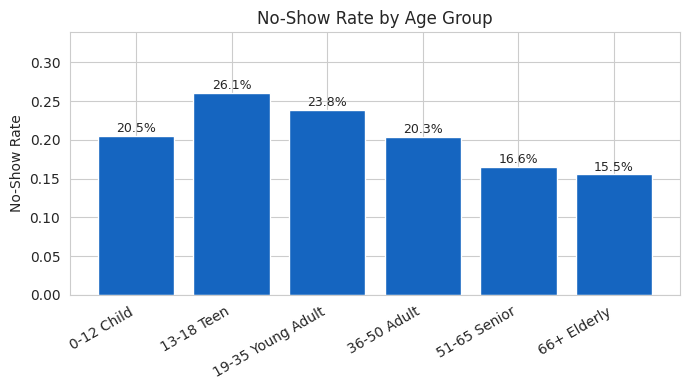

In [3]:
age_group_order = ['0-12 Child','13-18 Teen','19-35 Young Adult','36-50 Adult','51-65 Senior','66+ Elderly']
age_stats = df.groupby('age_group')['no_show_flag'].agg(volume='count', no_show_rate='mean').reindex(age_group_order)
age_stats['no_show_rate'] = age_stats['no_show_rate'].round(4)
print(age_stats)

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(age_stats.index, age_stats['no_show_rate'], color='#1565C0')
ax.set_title('No-Show Rate by Age Group')
ax.set_ylabel('No-Show Rate')
ax.set_ylim(0, age_stats['no_show_rate'].max()*1.3)
for i, v in enumerate(age_stats['no_show_rate']):
    ax.text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/B_age_group.png')
plt.show()


**Key insight:** no-show rate falls fairly steadily with age, from **26.1%** for teens (13-18) down to
**15.5%** for the 66+ group. Younger adults (19-35) are also relatively high at **23.8%**. Children (0-12) sit at
**20.5%** — close to the overall average (these are presumably attended by a guardian, not the child directly).

## C. Gender Analysis

**Business question:** Does gender meaningfully affect attendance? We report the actual difference and avoid
overstating it if it's small.


In [4]:
gender_stats = df.groupby('gender')['no_show_flag'].agg(volume='count', no_show_rate='mean')
print(gender_stats)
diff_pp = (gender_stats.loc['F','no_show_rate'] - gender_stats.loc['M','no_show_rate']) * 100
print(f"\nDifference (F - M): {diff_pp:.2f} percentage points")


        volume  no_show_rate
gender                      
F        71836      0.203115
M        38685      0.199638



Difference (F - M): 0.35 percentage points


**Key insight:** the gender gap is small (**0.35 percentage points**, F: 20.3% vs M: 20.0%) — not
large enough to treat gender as a meaningful operational lever on its own.

## D. Waiting / Lead Time Analysis

**Business question:** Does the amount of advance notice (lead time) affect whether a patient shows up? This is
expected to be one of the strongest drivers, based on the Phase 2 Excel audit.


                    volume  no_show_rate
waiting_time_group                      
Same day             38562      0.046471
1-3 days             14675      0.228893
4-7 days             17510      0.252027
8-14 days            12025      0.304699
15-30 days           17371      0.325888
31+ days             10378      0.330025

Point-biserial correlation (lead_time_days vs no_show_flag): 0.186


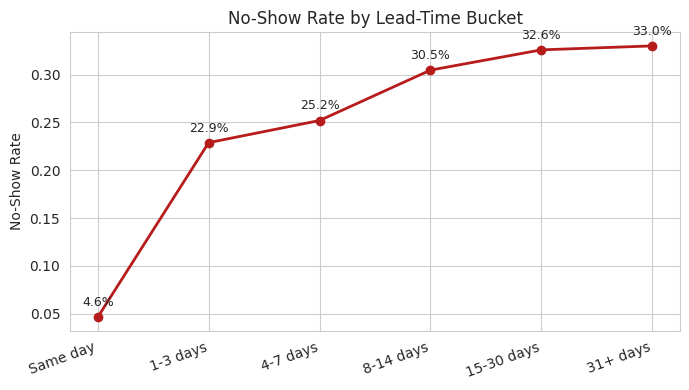

In [5]:
bucket_order = ['Same day','1-3 days','4-7 days','8-14 days','15-30 days','31+ days']
lead_stats = df.groupby('waiting_time_group')['no_show_flag'].agg(volume='count', no_show_rate='mean').reindex(bucket_order)
print(lead_stats)

corr = df[['lead_time_days','no_show_flag']].corr().iloc[0,1]
print(f"\nPoint-biserial correlation (lead_time_days vs no_show_flag): {corr:.3f}")

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(lead_stats.index, lead_stats['no_show_rate'], marker='o', color='#B71C1C', linewidth=2)
ax.set_title('No-Show Rate by Lead-Time Bucket')
ax.set_ylabel('No-Show Rate')
for i, v in enumerate(lead_stats['no_show_rate']):
    ax.annotate(f"{v:.1%}", (i, v), textcoords="offset points", xytext=(0,8), ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/D_lead_time.png')
plt.show()


**Key insight:** this is the strongest pattern seen so far and it's monotonic: no-show rate rises from
**4.6% (same day)** to **33.0% (31+ days)** — roughly a **7x increase**. The correlation coefficient (0.186) is
modest in absolute terms (no single factor here is huge alone) but this is the clearest, most consistent signal
in the dataset.

## E. Reminder / SMS Analysis

**Business question:** Is SMS reminder receipt associated with attendance?

**Important:** this is an observational comparison, not a controlled experiment. If reminders are sent more
often to patients with longer lead times (who are already more likely to no-show for unrelated reasons), a naive
comparison could make reminders look harmful even if they genuinely help. We check for that confound below.


In [6]:
sms_stats = df.groupby('sms_received')['no_show_flag'].agg(volume='count', no_show_rate='mean')
sms_stats.index = sms_stats.index.map({0: 'No SMS', 1: 'SMS Received'})
print(sms_stats)

# Check the suspected confound: does lead time differ by SMS status?
lead_by_sms = df.groupby('sms_received')['lead_time_days'].mean()
print("\nAverage lead time by SMS status:")
print(lead_by_sms)


              volume  no_show_rate
sms_received                      
No SMS         75039      0.166980
SMS Received   35482      0.275745

Average lead time by SMS status:
sms_received
0     6.007983
1    19.016713
Name: lead_time_days, dtype: float64


In [7]:
# Controlling for the confound: compare no-show rate by SMS status *within* the same lead-time bucket
sms_within_bucket = df.groupby(['waiting_time_group','sms_received'])['no_show_flag'].mean().unstack()
sms_within_bucket.columns = ['No SMS','SMS Received']
sms_within_bucket = sms_within_bucket.reindex(bucket_order)
print(sms_within_bucket)


                      No SMS  SMS Received
waiting_time_group                        
Same day            0.046471           NaN
1-3 days            0.229937      0.213024
4-7 days            0.271112      0.239711
8-14 days           0.337582      0.281125
15-30 days          0.368705      0.298004
31+ days            0.375252      0.302028


**Key insight — resolving the SMS puzzle:** the naive comparison (cell above) suggested SMS reminders
are associated with a *higher* no-show rate (27.6% vs 16.7%), which looks backwards. But average lead time is
**19.0 days for SMS recipients vs only 6.0 days for non-recipients** — clinics likely only have time to send a
reminder when the appointment was booked well in advance, and long lead time is independently linked to no-shows.

Once we compare SMS vs no-SMS **within the same lead-time bucket**, the pattern flips: in every bucket, SMS
recipients have a **lower** no-show rate than non-recipients (e.g. 15-30 days: 29.8% with SMS vs 36.9% without).
This is still observational, not a randomized experiment, but it's a much more defensible read than the naive
comparison, and it argues against dropping the reminder program.

## F. Weekday Analysis

**Business question:** Are certain weekdays worse for attendance?


                     volume  no_show_rate
appointment_weekday                      
Monday                22713      0.206446
Tuesday               25638      0.200874
Wednesday             25866      0.196861
Thursday              17246      0.193494
Friday                19019      0.212261
Saturday                 39      0.230769

Note: no Sunday appointments exist in this dataset; Saturday volume is very small (39 appointments) - interpret Saturday with caution.


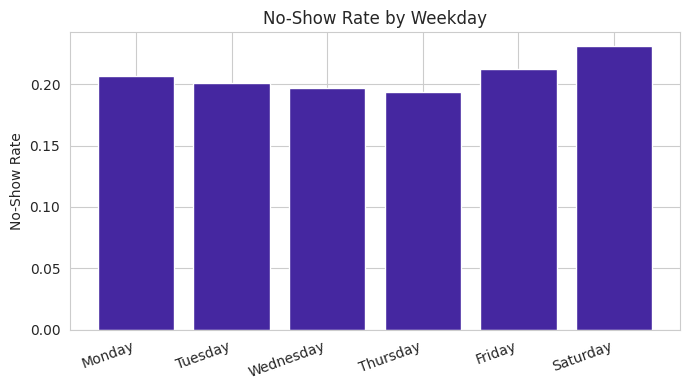

In [8]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
weekday_stats = df.groupby('appointment_weekday')['no_show_flag'].agg(volume='count', no_show_rate='mean').reindex(weekday_order)
print(weekday_stats)
print("\nNote: no Sunday appointments exist in this dataset; Saturday volume is very small "
      f"({int(weekday_stats.loc['Saturday','volume'])} appointments) - interpret Saturday with caution.")

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(weekday_stats.index, weekday_stats['no_show_rate'], color='#4527A0')
ax.set_title('No-Show Rate by Weekday')
ax.set_ylabel('No-Show Rate')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/F_weekday.png')
plt.show()


**Key insight:** weekday differences are small — no-show rate ranges from **19.3% (Thursday)** to
**21.2% (Friday)** among the weekdays with real volume. Saturday's 23.1% is based on only 39 appointments and
should not be treated as reliable. There are no Sunday appointments in this dataset at all.

## G. Appointment Time (Morning/Afternoon/Evening)

**Confirmed in Phase 1:** `appointment_day` in this dataset has **no time component** (always midnight) — only
the booking timestamp (`scheduled_day`) has a real time. There is therefore no way to know the actual time of day
of the visit itself, so **this analysis is skipped** rather than built on invented data.


## H. Location / Neighbourhood Analysis

**Business question:** Which neighbourhoods have high volume, and among those, which have high no-show rates?
We restrict "high no-show rate" ranking to neighbourhoods with a reasonably large sample, to avoid treating a
handful of appointments as a reliable rate.


In [9]:
neigh_stats = df.groupby('neighbourhood')['no_show_flag'].agg(volume='count', no_show_rate='mean')

print("Top 10 neighbourhoods by volume:")
print(neigh_stats.sort_values('volume', ascending=False).head(10))

VOLUME_THRESHOLD = 100
qualifying = neigh_stats[neigh_stats['volume'] >= VOLUME_THRESHOLD]
print(f"\n{len(qualifying)} of {len(neigh_stats)} neighbourhoods have >= {VOLUME_THRESHOLD} appointments.")
print(f"\nTop 10 (of qualifying) by no-show rate:")
print(qualifying.sort_values('no_show_rate', ascending=False).head(10))


Top 10 neighbourhoods by volume:
                   volume  no_show_rate
neighbourhood                          
JARDIM CAMBURI       7717      0.189841
MARIA ORTIZ          5805      0.209991
RESISTÊNCIA          4430      0.204289
JARDIM DA PENHA      3877      0.162755
ITARARÉ              3514      0.262664
CENTRO               3334      0.210858
SANTA MARTHA         3131      0.158416
TABUAZEIRO           3131      0.182689
JESUS DE NAZARETH    2853      0.243954
BONFIM               2773      0.198341

74 of 81 neighbourhoods have >= 100 appointments.

Top 10 (of qualifying) by no-show rate:
                   volume  no_show_rate
neighbourhood                          
SANTOS DUMONT        1276      0.289185
SANTA CECÍLIA         448      0.274554
SANTA CLARA           506      0.264822
ITARARÉ              3514      0.262664
JESUS DE NAZARETH    2853      0.243954
HORTO                 175      0.240000
ILHA DO PRÍNCIPE     2266      0.234775
CARATOÍRA            2565      0.23

**Key insight:** the highest-volume neighbourhood (JARDIM CAMBURI, 7,717 appointments) has a
below-average no-show rate (18.9%). The neighbourhoods with the worst no-show rates among statistically
meaningful samples (SANTOS DUMONT 28.9%, SANTA CECÍLIA 27.5%, SANTA CLARA 26.5%) are mid-volume, not the busiest
locations — so "biggest" and "worst" are not the same places, which matters for where the clinic focuses
operational effort.

## I. Patient History (Repeat Patients)

**Business question:** Do patients with a history of no-shows tend to no-show again? This dataset supports this
because `patient_id` repeats across multiple appointments.


In [10]:
appts_per_patient = df.groupby('patient_id').size()
print("Patients with only 1 appointment:", (appts_per_patient == 1).sum())
print("Patients with 2+ appointments:", (appts_per_patient >= 2).sum())
print("Max appointments by a single patient:", appts_per_patient.max())

# For patients with 2+ appointments, sorted by date: does a prior no-show predict the next no-show?
df_sorted = df.sort_values(['patient_id', 'appointment_day'])
df_sorted['prior_no_show'] = df_sorted.groupby('patient_id')['no_show_flag'].shift(1)

has_history = df_sorted.dropna(subset=['prior_no_show'])
print(f"\nAppointments with a known PRIOR appointment: {len(has_history):,}")

history_stats = has_history.groupby('prior_no_show')['no_show_flag'].agg(volume='count', no_show_rate='mean')
history_stats.index = history_stats.index.map({0.0: 'Previous appt attended', 1.0: 'Previous appt was a no-show'})
print(history_stats)


Patients with only 1 appointment: 37920
Patients with 2+ appointments: 24378
Max appointments by a single patient: 88



Appointments with a known PRIOR appointment: 48,223
                             volume  no_show_rate
prior_no_show                                    
Previous appt attended        38413      0.179601
Previous appt was a no-show    9810      0.351580


**Key insight:** this is the single strongest pattern found in the entire EDA. Among appointments where
the patient has a known prior visit, a **previous no-show nearly doubles** the chance of the next appointment
also being a no-show (**35.2%** vs **18.0%** if the previous appointment was attended). This is a much stronger
signal than lead time, age, or reminders, and is a strong candidate for the risk-segmentation logic in Phase 7.

## J. Medical / Patient Characteristics

**Business question:** Are hypertension, diabetes, alcoholism, or degree of handicap associated with attendance?


In [11]:
for col in ['hypertension','diabetes','alcoholism']:
    stats = df.groupby(col)['no_show_flag'].agg(volume='count', no_show_rate='mean')
    stats.index = stats.index.map({0: f'No {col}', 1: f'Has {col}'})
    print(stats, "\n")

handicap_stats = df.groupby('handicap')['no_show_flag'].agg(volume='count', no_show_rate='mean')
print("By handicap degree (0-4):")
print(handicap_stats)

chronic_stats = df.groupby('chronic_condition_count')['no_show_flag'].agg(volume='count', no_show_rate='mean')
print("\nBy chronic condition count (0-3):")
print(chronic_stats)


                  volume  no_show_rate
hypertension                          
No hypertension    88720      0.208995
Has hypertension   21801      0.173020 

              volume  no_show_rate
diabetes                          
No diabetes   102578      0.203591
Has diabetes    7943      0.180033 

                volume  no_show_rate
alcoholism                          
No alcoholism   107161      0.201911
Has alcoholism    3360      0.201488 

By handicap degree (0-4):
          volume  no_show_rate
handicap                      
0         108282      0.202333
1           2040      0.178431
2            183      0.202186
3             13      0.230769
4              3      0.333333

By chronic condition count (0-3):
                         volume  no_show_rate
chronic_condition_count                      
0                         85306      0.209047
1                         17582      0.177966
2                          7377      0.177037
3                           256      0.179

**Key insight:** the tracked chronic conditions (hypertension, diabetes, alcoholism) are all associated
with **slightly lower**, not higher, no-show rates (e.g. hypertension: 17.3% vs 20.9% without) — plausibly because
patients managing an ongoing condition are more engaged with care. The handicap-degree breakdown is noisy at
levels 3-4 due to very small sample sizes (13 and 3 records) and shouldn't be treated as a reliable pattern.

## Summary

This notebook produced the raw evidence for Phase 5 (statistical validation) and Phase 13 (final business
findings). Key candidate drivers to carry forward: lead time (strong, monotonic pattern), reminder status
(confounded with lead time — needs the controlled comparison above, not the naive one), age group, and specific
high-volume/high-no-show neighbourhoods. Weekday, gender, and individual medical conditions show comparatively
smaller differences and will be sized precisely in Phase 5.
